# LeetCode #101: Symmetric Tree

https://leetcode.com/problems/symmetric-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Serialize & Compare | O(n) | O(n) | Build string, compare equality |
| BFS with Queue Pairs | O(n) | O(n) | Enqueue mirror pairs, compare |
| **DFS Recursive (isMirror) ★** | **O(n)** | **O(n)** | Compare left.left==right.right & left.right==right.left |

---

## Understanding the Methods

### Brute Force (Serialize)
Serialize the tree to a string representation and check if the string reads the same forwards and backwards (mirrored). Simple but requires extra string allocation.

### BFS with Queue Pairs
Use a queue storing pairs of nodes that should be mirrors. Dequeue a pair, compare values, then enqueue (left.left, right.right) and (left.right, right.left). O(n) time and space.

### DFS Recursive (Optimal ★)
Define `isMirror(left, right)`: if both null → true; if one null or values differ → false; else recurse `isMirror(left.left, right.right) && isMirror(left.right, right.left)`. Clean O(n)/O(n) solution.

## Constraints
- Number of nodes: [1, 1000]
- Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsSymmetric(TreeNode root) {
        return IsMirror(root?.left, root?.right);
    }

    private bool IsMirror(TreeNode left, TreeNode right) {
        if (left == null && right == null) return true;
        if (left == null || right == null) return false;
        if (left.val != right.val)         return false;
        return IsMirror(left.left,  right.right) &&
               IsMirror(left.right, right.left);
    }
}

### Python

In [ ]:
class Solution:
    def isSymmetric(self, root) -> bool:
        def is_mirror(left, right) -> bool:
            if not left and not right:
                return True
            if not left or not right:
                return False
            return (left.val == right.val and
                    is_mirror(left.left,  right.right) and
                    is_mirror(left.right, right.left))
        return is_mirror(root.left, root.right)

### Go

In [ ]:
func isSymmetric(root *TreeNode) bool {
    return isMirror(root.Left, root.Right)
}

func isMirror(left, right *TreeNode) bool {
    if left == nil && right == nil {
        return true
    }
    if left == nil || right == nil {
        return false
    }
    return left.Val == right.Val &&
        isMirror(left.Left,  right.Right) &&
        isMirror(left.Right, right.Left)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn is_symmetric(root: Option<Rc<RefCell<TreeNode>>>) -> bool {
        fn is_mirror(
            left:  Option<Rc<RefCell<TreeNode>>>,
            right: Option<Rc<RefCell<TreeNode>>>,
        ) -> bool {
            match (left, right) {
                (None, None)   => true,
                (None, _) | (_, None) => false,
                (Some(l), Some(r)) => {
                    if l.borrow().val != r.borrow().val { return false; }
                    is_mirror(l.borrow().left.clone(),  r.borrow().right.clone()) &&
                    is_mirror(l.borrow().right.clone(), r.borrow().left.clone())
                }
            }
        }
        match root {
            None    => true,
            Some(r) => is_mirror(r.borrow().left.clone(), r.borrow().right.clone()),
        }
    }
}

## Example Scenarios

### 1. Common Case — Classic Symmetric Tree
**Input:** `root = [1, 2, 2, 3, 4, 4, 3]`

isMirror(2, 2): values match. isMirror(left.left=3, right.right=3): match. isMirror(left.right=4, right.left=4): match. All leaf nulls match. Perfect mirror around the root.

*Why tricky:* Standard symmetric case verifying the cross-comparison: `left.left` vs `right.right` and `left.right` vs `right.left`.

$n = 7$. Mirror pairs: $(2,2), (3,3), (4,4)$. $O(n)$ time.

**Output:** `true`

---

### 2. Slightly Complex — Same Values, Asymmetric Structure
**Input:** `root = [1, 2, 2, null, 3, null, 3]`

isMirror(2, 2): match. isMirror(left.left=null, right.right=3): one null, one node → false! Left child has null-left, but right child has 3-right — not mirrors.

*Why tricky:* All non-null values are the same $\{1,2,2,3,3\}$ but the structure is not mirrored. Tests that placement matters, not just value equality.

Short-circuits after 2 calls. Only 2 of 5 nodes examined.

**Output:** `false`

---

### 3. Edge Case: Time Factor — Perfect Symmetric Tree, 1000 Nodes
**Input:** perfect symmetric tree of $\approx 1000$ nodes (depth 9)

All mirror pairs match. Must visit every node since the tree is fully symmetric. No early exit possible. DFS checks all $n/2 = 500$ mirror pairs.

*Why tricky:* Maximum $n = 1000$ with no short-circuit. Worst-case time for a true answer: every mirror pair must be verified.

$n \approx 1000$, depth $\approx 10$. Mirror pairs $= 500$. Stack depth $= O(\log n) \approx 10$.

**Output:** `true`

---

### 4. Edge Case: Space Factor — Symmetric Zigzag (Max Recursion)
**Input:** root with 1000 nodes forming a symmetric zigzag (left side: left-right-left-..., right side mirrors)

Both sides zigzag to depth 500. The isMirror recursion follows both branches 500 levels deep. Stack depth $= n/2$ = worst case for space.

*Why tricky:* Worst-case stack space $O(n/2)$. Symmetric zigzag forces maximum recursion depth while maintaining symmetry.

Stack depth $= n/2 = 500$. Each frame stores two node pointers.

**Output:** `true`

---

### 5. Almost-Impossible but Plausible — Boundary Values, All Same Per Level
**Input:** `root =` perfect tree of 15 nodes. Depth-0: val $= 100$. Depth-1: val $= 100$. Depth-2: val $= 100$. Depth-3: val $= -100$.

Every mirror pair matches because same-depth nodes share the same value. Boundary values ($-100$, $100$, constraint limits) span the full range. The algorithm checks `left.val == right.val` purely — value magnitudes don't matter.

*Why tricky:* Boundary values at both extremes. Symmetry is per-level, so every node at the same depth has the same value. Algorithm must still verify cross-structure pairing, not just per-level checks.

$n = 15 = 2^4 - 1$. Values span $[-100, 100]$. 7 mirror pairs + 16 null checks.

**Output:** `true`

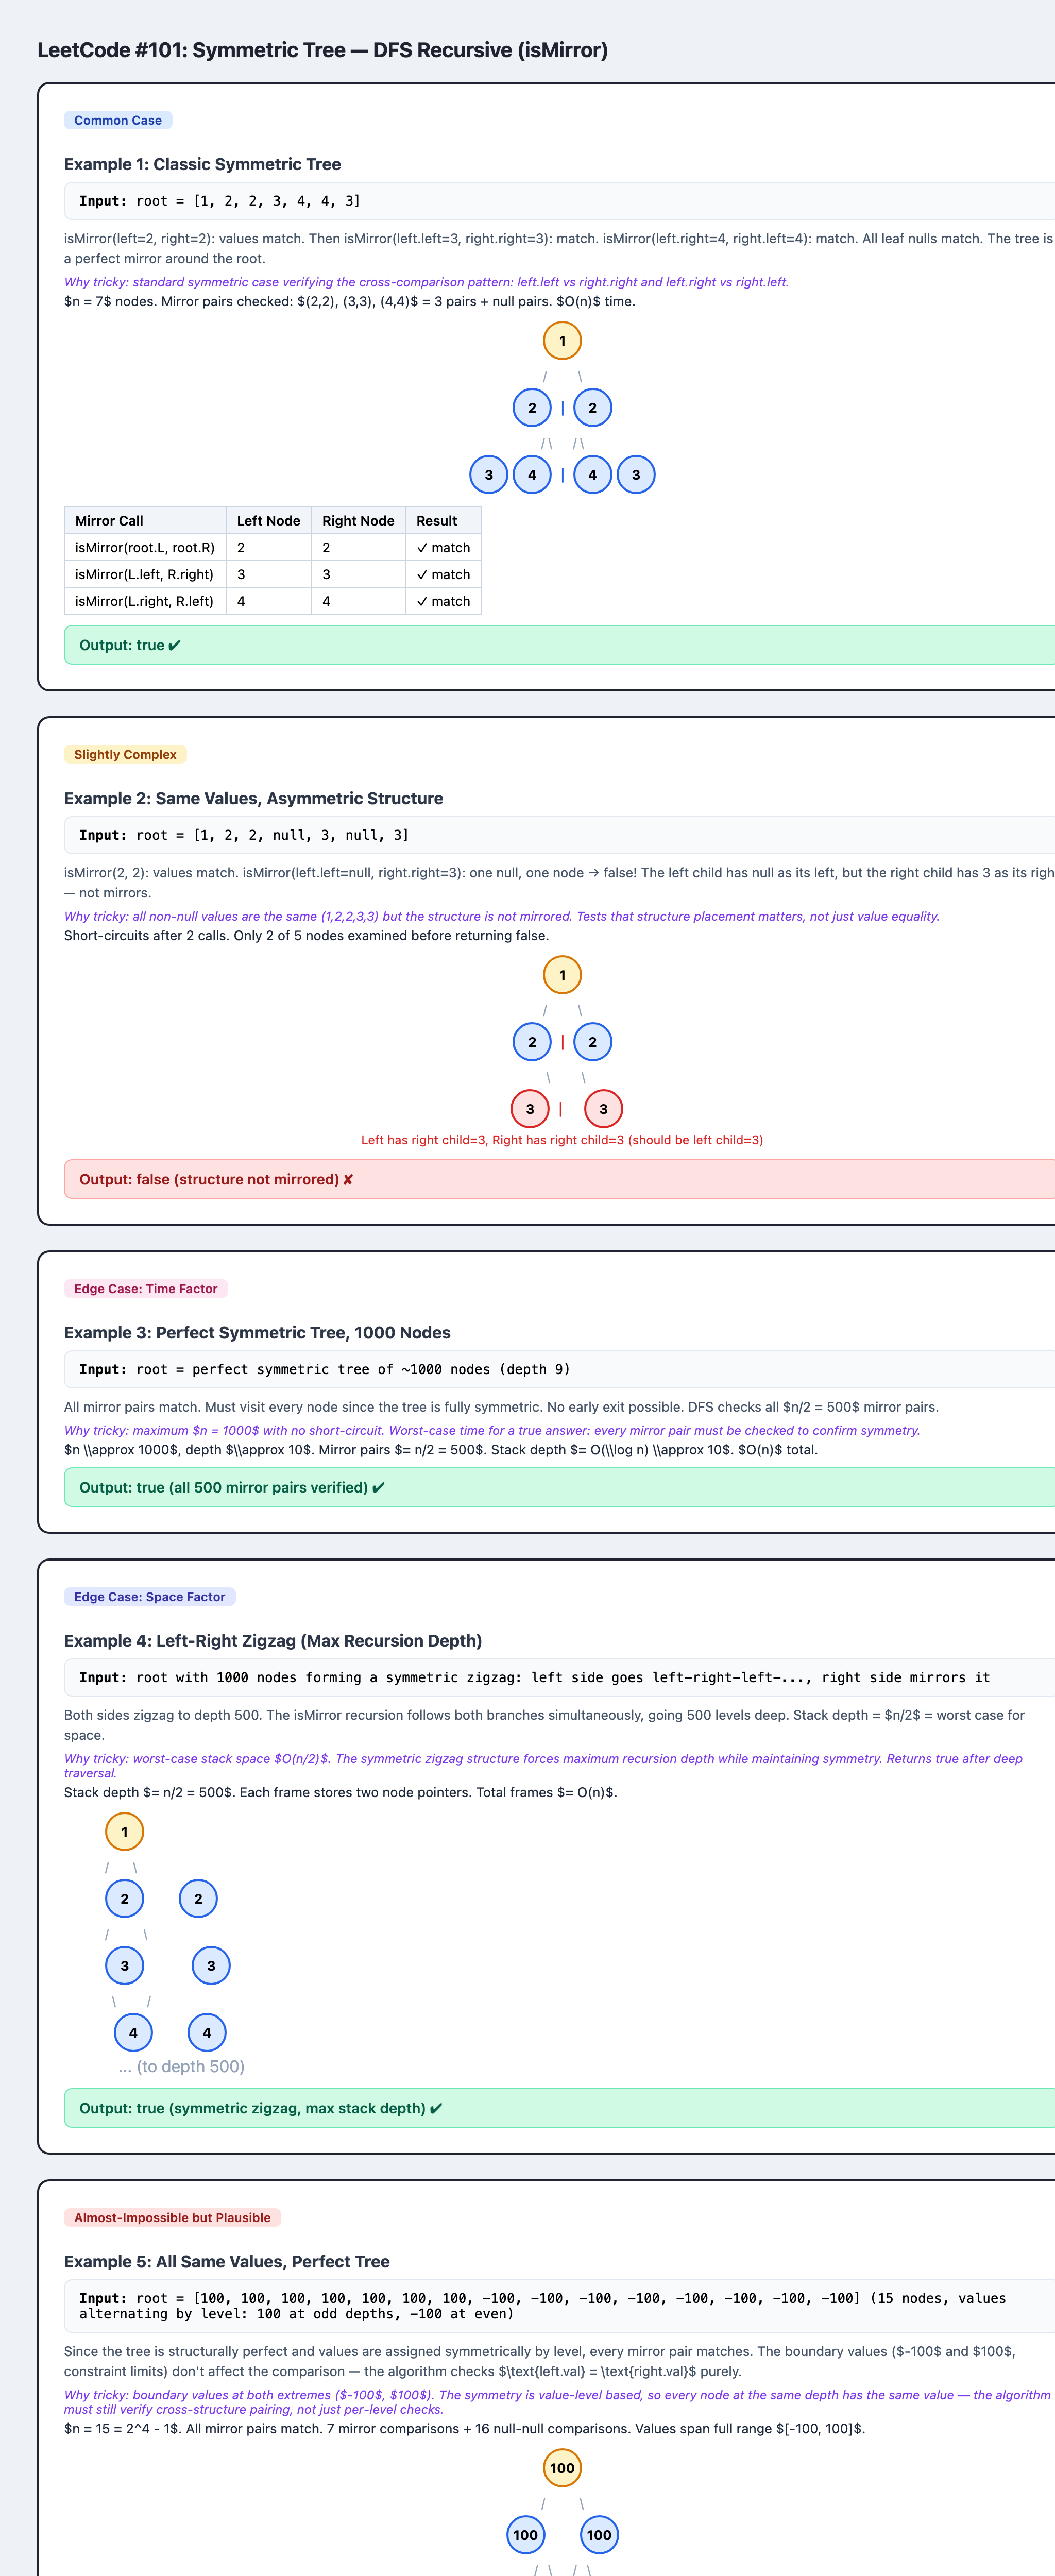